# تغيير فضاءات الالوان: 
## الهدف:

سنتعلم هنا كيف نحول الصور من فضاء لوني لاخر,
بالاضافة لذلك سننشئ تطبيقاً لاشتقاق جسم ملون بفيديو 
,
وسنتعلم التوابع التالية :
`cv2.cvtColor` , `cv2.inRange`

## تغيير الفضاء اللوني:

هناك اكثر من 150 طريقة لتغيير الفضاءات اللونية ب
**OpenCV**
ولكننا سننظر فقط الى اثنين هما الاكثر استخداماً
وللتغير اللوني سنستخدم التابع التالي: 
 `cv2.cvtColor(input_image, flag)`
حيث قيمة العلم تدل على نوع التغيير , مثلا من:

$$ BGR \rightarrow GRAY $$

نستخدم: 
`cv2.COLOR_BGR2GRAY` ,أما `cv2.COLOR_BGR2HSV`
 طبعاً للتحويل من 
$$ BGR \rightarrow  HSV $$
 ولمعرفة كل الاعلام الاخرى بامكانك تشغيل الكود التالي:


In [1]:
import cv2
flags = [i for i in dir(cv2) if i.startswith('COLOR_')]
for x in flags:
    print x

COLOR_BAYER_BG2BGR
COLOR_BAYER_BG2BGR_VNG
COLOR_BAYER_BG2GRAY
COLOR_BAYER_BG2RGB
COLOR_BAYER_BG2RGB_VNG
COLOR_BAYER_GB2BGR
COLOR_BAYER_GB2BGR_VNG
COLOR_BAYER_GB2GRAY
COLOR_BAYER_GB2RGB
COLOR_BAYER_GB2RGB_VNG
COLOR_BAYER_GR2BGR
COLOR_BAYER_GR2BGR_VNG
COLOR_BAYER_GR2GRAY
COLOR_BAYER_GR2RGB
COLOR_BAYER_GR2RGB_VNG
COLOR_BAYER_RG2BGR
COLOR_BAYER_RG2BGR_VNG
COLOR_BAYER_RG2GRAY
COLOR_BAYER_RG2RGB
COLOR_BAYER_RG2RGB_VNG
COLOR_BGR2BGR555
COLOR_BGR2BGR565
COLOR_BGR2BGRA
COLOR_BGR2GRAY
COLOR_BGR2HLS
COLOR_BGR2HLS_FULL
COLOR_BGR2HSV
COLOR_BGR2HSV_FULL
COLOR_BGR2LAB
COLOR_BGR2LUV
COLOR_BGR2RGB
COLOR_BGR2RGBA
COLOR_BGR2XYZ
COLOR_BGR2YCR_CB
COLOR_BGR2YUV
COLOR_BGR2YUV_I420
COLOR_BGR2YUV_IYUV
COLOR_BGR2YUV_YV12
COLOR_BGR5552BGR
COLOR_BGR5552BGRA
COLOR_BGR5552GRAY
COLOR_BGR5552RGB
COLOR_BGR5552RGBA
COLOR_BGR5652BGR
COLOR_BGR5652BGRA
COLOR_BGR5652GRAY
COLOR_BGR5652RGB
COLOR_BGR5652RGBA
COLOR_BGRA2BGR
COLOR_BGRA2BGR555
COLOR_BGRA2BGR565
COLOR_BGRA2GRAY
COLOR_BGRA2RGB
COLOR_BGRA2RGBA
COLOR_BGRA2YUV_I420
C

###  ملاحظة:

من اجل الفضاء 
**HSV**
مجال السطوع هو : [0,179] مجال الاشباع :[0,255] ومجال القيمة هو [0,255]. القيم قد تختلف من برنامج لاخر . لذلك يجب مراعاة التحويل المناسب عند الانتقال اليها.


## تعقب الاجسام

نعلم الان كيفية التحويل اللوني , ويمكننا استخدام هذا لاشتقاق جسم ملون , بالفضاء
**HSV**
و يمكن تمثيل الالوان بسهولة اكبر مما بالفضاء 
**BGR**

:وبتطبيقنا سنحاول اشتقاق جسم ملون ازرق  والتالي هو الطريقة

- خذ كل اطار من الفيديو

-  حول من فضاء لاخر 

- خذ قيمة العتبة للصورة المحولة من اجل قيمة اللون المطلوبة ( الازرق) هنا

- اشتق الجسم الملون الان ويمكن استخدام النتيجة الان لما تريده

التالي هو البرنامج المفصل مع التعليقات:


In [2]:
%matplotlib inline

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

cap = cv2.VideoCapture(0)

while (1):
    
    # Take each frame
    _, frame = cap.read()
    
    # Convert BGR to HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    # define range of blue color in HSV
    lower_blue = np.array([110,50,50])
    upper_blue = np.array([130,255,255])
    
    # Threshold the HSV image to get only blue colors
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    # Bitwise-AND mask and original image
    res = cv2.bitwise_and(frame,frame, mask= mask)
    
    cv2.imshow('frame' ,frame)
    cv2.imshow('mask',mask)
    cv2.imshow('res',res)
    k = cv2.waitKey(5)
    if k == 27:
        break
        
cv2.destroyAllWindows()

الصور ادناه تظهر اكتشاف الجسم الازرق , ولكن بسبب آلية الاظهار في 
**matplotlib **
يبدو احمر

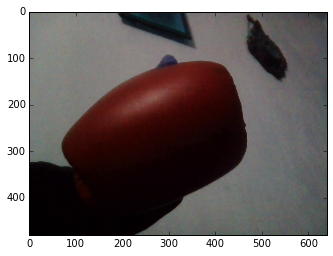

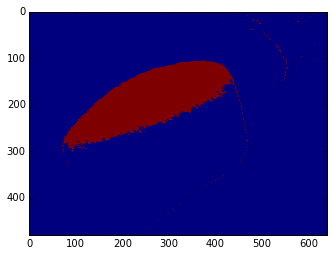

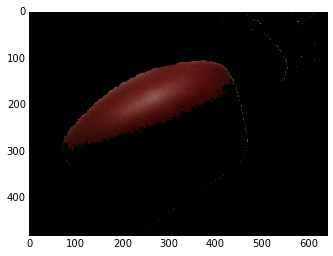

In [15]:
plt.imshow(frame)
plt.show()
plt.imshow(mask)
plt.show()
plt.imshow(res)
plt.show()

لاحظ انه هناك بعض الضجيج في الصورة , سنرى بفصول لاحق كيف نزيلهم
###  ملاحظة:

هذه ابسط الطرق لتعقب الاجسام , ومتى احترفت توابع الاطارات بامكانك القيام بالعديد من الاشياء مثل ايجاد مركز الجسم , واستخدامه لتعقب الاجسام , ورسم البيانات فقط من خلال تحريك يدك امام كاميرا , والعديد من الاشياء الممتعة الاخرى


## كيف يمكنك تحديد القيم اللونية اللازم تعقبها:

هذا سؤال شائع , في 
**stackoverflow.com**
وهذا بغاية السهولة  وبامكانك استخدام نفس التابع , 
`cv2.cvtColor`
بدلا من تمرير صورة الرمادية , يمكنك تمرير الصورة الملونة 
التي ترغب بها , مثلا , لايجاد القيمة الموافقة للاخضر , جرب التالي بطرفية بايثون:

In [6]:
green = np.uint8([[[0,255,0 ]]])
hsv_green = cv2.cvtColor(green,cv2.COLOR_BGR2HSV)
print hsv_green

[[[ 60 255 255]]]


والان يمكنك اخذ

$$[H-10 , 100 ,100]$$ و $$[H+10,255,255] $$

كحد ادنى وحد اعلى بالترتيب .

وإضافة لهذه الطريقة , يمكنك استخدام اي ادوات تحرير صور , او محولات على الانترنت لايجاد هذه القيم ولكن لاتنسى تعديل المجالات

### تمرين غير محلول:

جرب ايجاد طريقة لاشتقاق اكثر من جسم ملون بنفس الوقت , مثلا الاجسام الحمراء والزرقاء والخضراء

# تحويل العتبة للصور:
الهدف:

- في هذا القسم سنتعلم , *التعتيب البسيط* , *التعتيب المتكيف* ,و*التعتيب وفق اوتسو*
`Otsu`

- وسنتعلم هذه التوابع 
`cv2.threshold` , `cv2.adaptiveThreshold`


##  التعتيب البسيط:

هنا القضية بسيطة , اذا فاقت قيمة البكسل قيمة محددة , فيسند له 1 (ربما ابيض)والا يسند له 0 (ربما اسود)والتابع المستخدم هو
`cv2.threshold`

واول متغير له هو الصورة المصدر التي يجب ان تكون رمادية (مستوي واحد)والمتغير الثاني هو العتبة التي سنصنف البكسلات من خلالها
, المتغير الثالث هو القيمة العظمى للبكسل الاكبر من العتبة كناتج والمكتبة
**Opencv**
تعطي عدة خيارات للتعتيب وهذه تتحدد بالمتغير الثالث, أما المتغير الرابع فهو أحد التالي:

- cv2.THRESH_BINARY
- cv2.THRESH_BINARY_INV
- cv2.THRESH_TRUNC
- cv2.THRESH_TOZERO
- cv2.THRESH_TOZERO_INV

والتوثيق يشرح بالتفصيل وضع كل واحدة منها , وهناك خرجان , اولهما هو المرتجع الذي سيشرح لاحقا والاخر هو الصورة المعتبة الثنائية والبرنامج كما يلي:


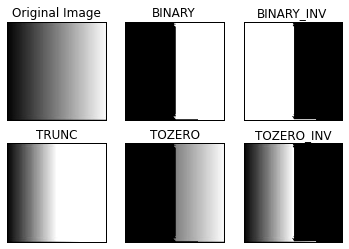

In [17]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('gradient.bmp',0)
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in xrange(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
    
plt.show()

###  ملاحظة: 
لاظهار اكثر من صورة استخدمنا تابع
`plt.subplot`

لمزيد من الشرح يمكنك مراجعة التعليمات الخاصة بها.

## التعتيب المتكيف:

في الفصل السابق استخدمنا قيمة شاملة كقيمة للعتبة , ولكن قد لايكون هذا جيدا حيث تملك الصور شروط اضاءة مختلفة باماكن مختلفة
وهنا يمكننا استخدام التعتيب المتكيف , حيث نأخذ جزءاً صغيراً , ونضع عتبة خاصة به , وبذلك نحصل على عدة عتبات للصورة نفسها , وهذا سيعطي نتائج افضل للصور مع لمعان , مختلف.
ولديه ثلاث مداخيل خاصة ومتغير خرج وحيد

### الطريقة المتكيفة

وهذه تقرر كيف تحسب قيمة العتبة

- cv2.ADAPTIVE_THRESH_MEAN_C:
قيمة التعتيب هي المتوسط لمساحة الجوار

- cv2.ADAPTIVE_THRESH_GAUSSIAN_C:
قيمة التعتيب هي المتوسط الموزون لمساحة الجوار , والاوزان هي النافذة الغاوسية

- مساحة الوحدة :
وهي تقرر مساحة الجوار المرغوب

- C :
وهذا ثابت يطرح من المتوسط او المتوسط الموزون المحسوب

البرنامج التالي يقارن التعتيب الشامل والمتكيف لاجل صورة متغيرة الاضاءة:


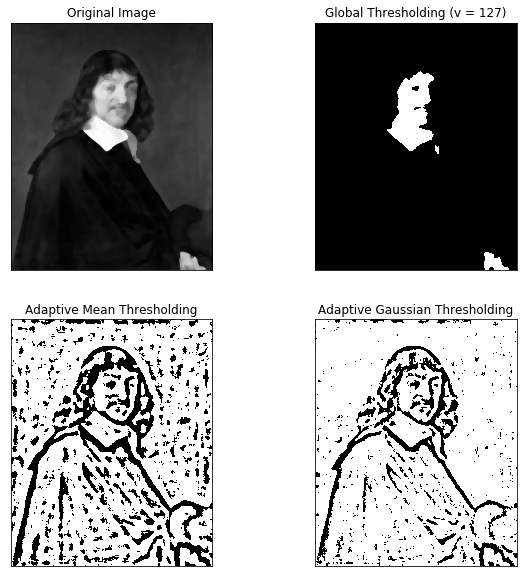

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('Rene_Decart.jpg',0)
img = cv2.medianBlur(img,5)

ret,th1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
th2 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,11,2)
th3 = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,11,2)

titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
plt.figure(figsize=[10,10])
for i in xrange(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

من الواضح انه بالتعتيب المتكيف , النتائج تكون افضل والضجيج اقل.

## التحويل الثنائي لاوتسو

كما اوضحنا بالقسم السابق انه هناك متغير اخر لعملية التعتيب , فما عمله ؟؟
ما كنا نفعله بحالة التعتيب البسيط اننا نحدد العتبة ثم عن طريق التجربة والخطأ نحدد القيم المثالية , لها , ولكن اذا كان لدينا صورة
**bimodal**
(ببساطة صورة للهستوغرام تميزها ذروتان)
لهذه الصورة , سنأخذ قيمة عتبة وسطياً بين الذروتين , وهذا هو ما يفعله تحويل اوتسو .

وبعبارة بسيطة فانه يحسب قيمة العتبة من اجل الصور ثنائية الحالة , اما لباقي الصور فلن يكون التحويل الثنائي دقيقاً
ولتطبيق هذا نستخدم
`cv2.THRESH_OTSU`
في تابع التعتيب
ولقيمة العتبة , مرر صفراً ببساطة , وعندها توجد الخوارزمية القيمة المثالية , وتعيده بالخرج الثاني , واذا لم يتم استخدام اوتسو فسيكون هذا الخرج نفسه هو المحدد بالدخل
لنفحص المثال ادناه . صورة الدخل ذات ضجيج , في الحالة الاولى نطبق التعتيب الشامل , في الحالة الثانية نطبق التعتيب حسب ْاوتسو , في الحالة الثالثة , نطبق مرشح غاوسي بحجم 5 لازالة الضجيج , وبعدها نطبق ترشيح اوتسو .  لاحظ كيف تحسن فلترة الضجيج النتائج


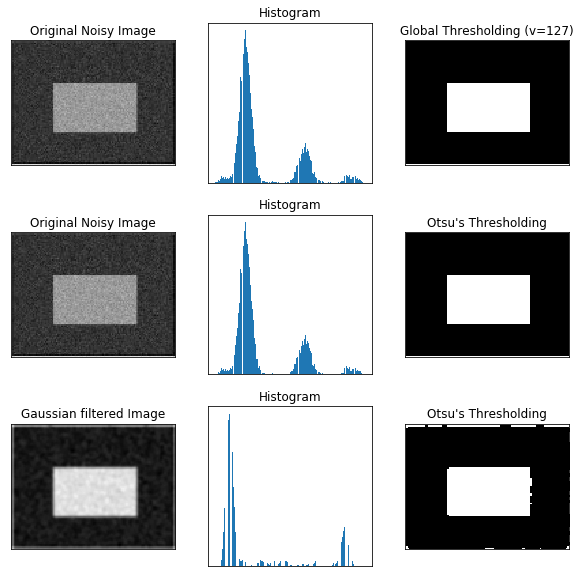

In [11]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('noisy.bmp',0)

# global thresholding
ret1,th1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

# Otsu's thresholding
ret2,th2 = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# Otsu's thresholding after Gaussian filtering
blur = cv2.GaussianBlur(img,(5,5),0)
ret3,th3 = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# plot all the images and their histograms
images = [img, 0, th1,
    img, 0, th2,
    blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
        'Original Noisy Image','Histogram',"Otsu's Thresholding",
        'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
plt.figure(figsize=[10,10])
for i in xrange(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

في السابق , تظهر نقاط مشتتة في الصور , ولكن بترشيح الضجيج تزول
### تمارين:
هناك بعض طرق الامثلة المتوفرة , لتحويل اوتسو الثنائي , ابحث عنها وطبقها..
**Otsu’s binarization optimizations**